# Brain Tumor Detection

### Loading Data

In [ ]:
# Renaming images
# Example: from gg (127).jpg to gg__127_.jpg

import os
import re

def clean_filenames(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            old_path = os.path.join(root, filename)
            # Replace spaces and parentheses
            new_filename = re.sub(r"[ ()]", "_", filename)
            new_path = os.path.join(root, new_filename)
            if old_path != new_path:
                os.rename(old_path, new_path)

# Run it on your training dataset
# My data is one folder above the git project
clean_filenames("../data/archive/training")

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

training_path = "../data/archive/training"


# Use the VGG16-specific preprocessing function
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # THIS is important
    validation_split=0.2  # Create validation split from training set
)

train_generator = train_datagen.flow_from_directory(
    '../data/archive/training',
    target_size=(224, 224),      # Resize to VGG16 input
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '../data/archive/training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.


In [2]:
# Checking if the classes have been recognized

print("Class indices:", train_generator.class_indices)

Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..67.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..72.5305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..71.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..76.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..63.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..75.5305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..75.0305].
Clipping input data to the 

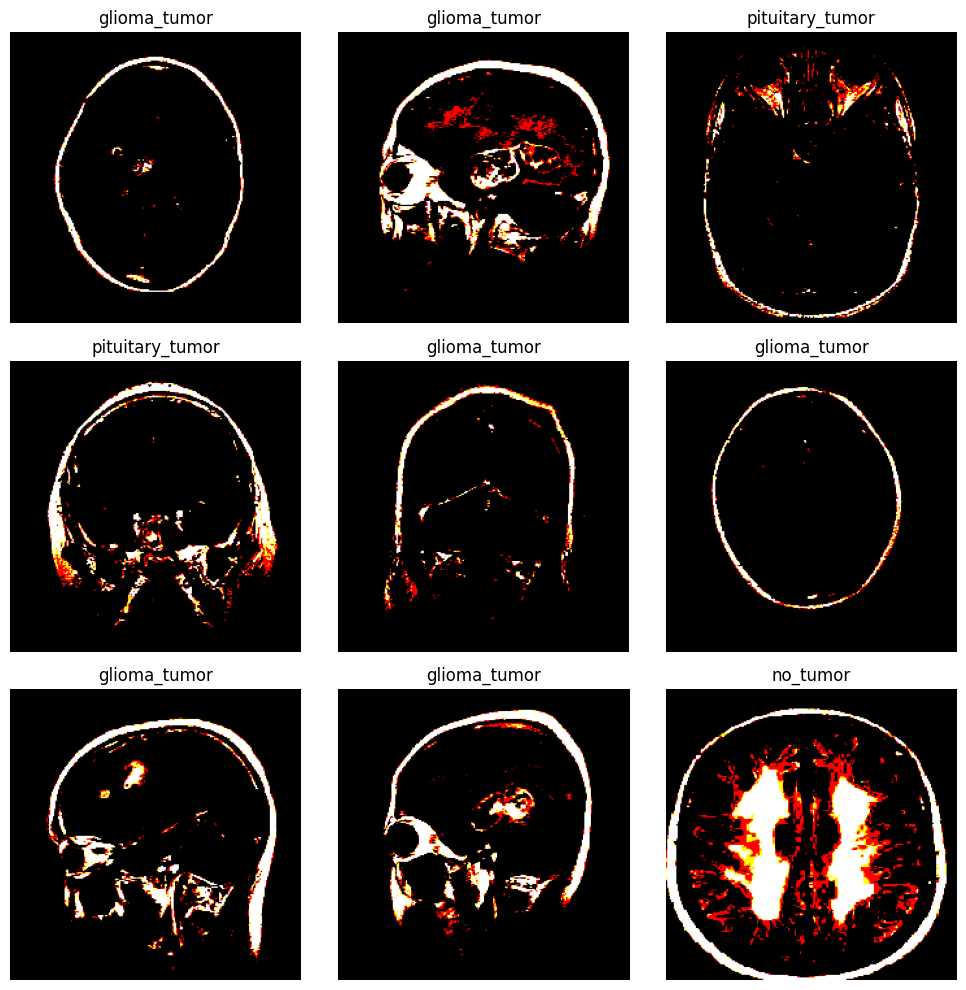

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of data
images, labels = next(train_generator)

# Get class names from generator
class_names = list(train_generator.class_indices.keys())

# Plot 9 sample images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] + 1) / 2)  # un-preprocess VGG input (optional)
    label_idx = np.argmax(labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.tight_layout()
plt.show()


# Images look different than the original ones because this is already preprocessed for CNN 




Found 2297 images belonging to 4 classes.


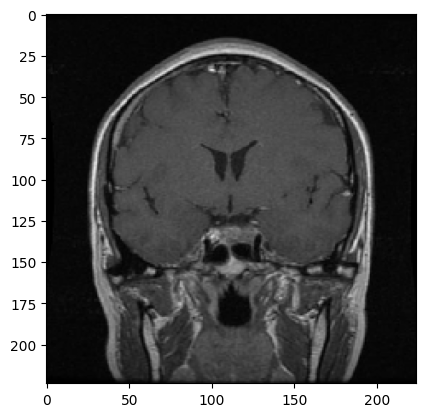

In [5]:
preview_datagen = ImageDataGenerator(validation_split=0.2)

preview_generator = preview_datagen.flow_from_directory(
    '../data/archive/training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

images, labels = next(preview_generator)

plt.imshow(images[0] / 255.0) 

# How the original data looks like